# Capítulo 9 · Primer modelo de Deep Learning

En los capítulos anteriores estudiamos por separado las piezas de una red neuronal: neuronas, capas, activaciones, pérdida, gradientes, backpropagation, batches, epochs y optimizadores. En este cuaderno las reuniremos por primera vez dentro de un flujo completo.

Construiremos una red pequeña para clasificar dos grupos con forma de medias lunas. Como cada observación tiene solo dos variables, podremos ver los datos y también la frontera de decisión que aprenda el modelo.

## Objetivos del cuaderno

Al finalizar este recorrido podrás:

- preparar un problema sencillo de clasificación binaria;
- relacionar la forma de los datos con la capa de entrada;
- construir la arquitectura $2\rightarrow8\rightarrow4\rightarrow1$ con Keras;
- comprobar el conteo de sus parámetros entrenables;
- compilar y entrenar la red con las decisiones estudiadas hasta ahora;
- distinguir datos de entrenamiento, validación y prueba;
- evaluar el modelo y convertir probabilidades en clases;
- visualizar una frontera de decisión no lineal;
- reconocer qué hace cada parte del flujo sin considerar `fit()` una caja negra.

## Importación de librerías

Usaremos NumPy y Pandas para organizar los resultados, Matplotlib para las visualizaciones, Scikit-learn para generar y dividir los datos, y TensorFlow/Keras para construir la red. El ejemplo es pequeño y puede ejecutarse con CPU.

In [1]:
import os

# Reduce mensajes técnicos que no forman parte de la práctica.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format

SEMILLA = 42
keras.utils.set_random_seed(SEMILLA)

print(f"TensorFlow: {tf.__version__}")
print("GPU disponible:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0
GPU disponible: False


## 1. Crear y observar el problema

Generaremos 1000 observaciones con `make_moons`. Cada fila contiene dos características, $x_1$ y $x_2$, y una etiqueta binaria, 0 o 1. El parámetro `noise=0.15` agrega pequeñas variaciones para que las curvas no sean perfectas.

Antes de construir la red, observaremos la forma de los datos, el balance de las clases y su distribución en el plano.

,Cantidad de observaciones,Cantidad de características,Clase 0,Clase 1
0,1000,2,500,500


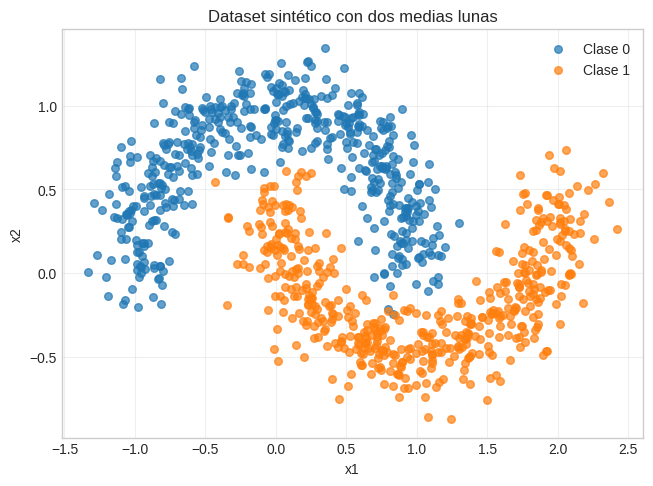

In [2]:
X, y = make_moons(
    n_samples=1000,
    noise=0.15,
    random_state=SEMILLA,
)

X = X.astype("float32")
y = y.astype("float32")

resumen_datos = pd.DataFrame({
    "Cantidad de observaciones": [len(X)],
    "Cantidad de características": [X.shape[1]],
    "Clase 0": [int((y == 0).sum())],
    "Clase 1": [int((y == 1).sum())],
})

display(resumen_datos)

fig, ax = plt.subplots(figsize=(7.5, 5.3))
ax.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    alpha=0.7,
    s=30,
    label="Clase 0",
)
ax.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    alpha=0.7,
    s=30,
    label="Clase 1",
)
ax.set_title("Dataset sintético con dos medias lunas")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Las dos clases contienen la misma cantidad de observaciones. Su geometría es curva y ambas regiones se entrelazan, por lo que una única recta no puede separarlas adecuadamente.

Esta forma hace visible el aporte de las capas ocultas y de las activaciones no lineales, sin agregar dificultades de preparación de datos que desvíen la atención del modelo.

## 2. Separar entrenamiento y prueba

Reservaremos el 20 % de las observaciones para la evaluación final. Esos datos de prueba no participarán en las actualizaciones de los parámetros.

Durante `fit()`, Keras apartará además el 20 % del conjunto de entrenamiento como validación. Esa porción permitirá registrar el comportamiento sobre datos que no actualizan los pesos. En el capítulo siguiente analizaremos esas curvas con más detalle.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEMILLA,
    stratify=y,
)

cantidad_prueba = len(X_test)
cantidad_validacion = int(len(X_train) * 0.20)
cantidad_entrenamiento_real = len(X_train) - cantidad_validacion

particiones = pd.DataFrame({
    "Uso": ["Entrenamiento real", "Validación durante fit()", "Prueba final"],
    "Cantidad aproximada": [
        cantidad_entrenamiento_real,
        cantidad_validacion,
        cantidad_prueba,
    ],
    "Actualiza parámetros": ["Sí", "No", "No"],
})

display(particiones)
print("Forma de X_train:", X_train.shape)
print("Forma de X_test: ", X_test.shape)

,Uso,Cantidad aproximada,Actualiza parámetros
0,Entrenamiento real,640,Sí
1,Validación durante fit(),160,No
2,Prueba final,200,No


Forma de X_train: (800, 2)
Forma de X_test:  (200, 2)


De las 1000 observaciones, 200 quedan reservadas para prueba. De las 800 restantes, unas 640 se utilizarán para actualizar parámetros y unas 160 para validación.

Las tres porciones cumplen funciones diferentes: aprender, observar el entrenamiento desde fuera y evaluar al final. La prueba debe permanecer separada hasta que el entrenamiento termine.

## 3. Construir la red $2\rightarrow8\rightarrow4\rightarrow1$

La arquitectura seguirá exactamente el modelo del capítulo:

$$
[x_1,x_2]
\rightarrow
\operatorname{Dense}(8,\operatorname{ReLU})
\rightarrow
\operatorname{Dense}(4,\operatorname{ReLU})
\rightarrow
\operatorname{Dense}(1,\operatorname{sigmoid})
$$

La entrada admite dos valores. Las capas ocultas utilizan ReLU para construir transformaciones no lineales. La neurona final usa sigmoid y produce un número entre 0 y 1, que interpretaremos como la probabilidad asignada a la clase 1.

In [4]:
keras.backend.clear_session()
keras.utils.set_random_seed(SEMILLA)

modelo = keras.Sequential([
    keras.Input(shape=(2,), name="entrada"),
    layers.Dense(8, activation="relu", name="oculta_1"),
    layers.Dense(4, activation="relu", name="oculta_2"),
    layers.Dense(1, activation="sigmoid", name="salida"),
], name="red_dos_lunas")

modelo.summary()

Model: "red_dos_lunas"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

La red contiene 65 parámetros entrenables. Podemos comprobar el cálculo capa por capa:

$$
\text{parámetros de una capa densa}
=
(\text{entradas}\times\text{neuronas})+\text{neuronas}
$$

El último término corresponde a un bias por neurona.

In [5]:
conteo_parametros = pd.DataFrame({
    "Capa": ["Oculta 1", "Oculta 2", "Salida"],
    "Entradas": [2, 8, 4],
    "Neuronas": [8, 4, 1],
    "Pesos": [2 * 8, 8 * 4, 4 * 1],
    "Bias": [8, 4, 1],
})
conteo_parametros["Total"] = (
    conteo_parametros["Pesos"] + conteo_parametros["Bias"]
)

display(conteo_parametros)
print("Total calculado:", conteo_parametros["Total"].sum())
print("Total informado por Keras:", modelo.count_params())

,Capa,Entradas,Neuronas,Pesos,Bias,Total
0,Oculta 1,2,8,16,8,24
1,Oculta 2,8,4,32,4,36
2,Salida,4,1,4,1,5


Total calculado: 65
Total informado por Keras: 65


El cálculo manual coincide con `summary()`: 24 parámetros en la primera capa, 36 en la segunda y 5 en la salida. En este modelo todos son entrenables.

La arquitectura ya permite producir una salida, pero todavía no contiene una solución aprendida para las dos lunas. Sus pesos y bias se encuentran en valores iniciales.

## 4. Compilar el modelo

La arquitectura define qué operaciones puede realizar la red. `compile()` agrega las decisiones necesarias para aprender:

- `binary_crossentropy` mide el error de una clasificación binaria;
- Adam utiliza los gradientes para actualizar los parámetros;
- `accuracy` registra la proporción de clases acertadas como métrica adicional.

Compilar configura el entrenamiento, pero todavía no lo ejecuta.

In [6]:
modelo.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("Pérdida:", modelo.loss)
print("Optimizador:", modelo.optimizer.__class__.__name__)
print("Cantidad de parámetros antes de entrenar:", modelo.count_params())

Pérdida: binary_crossentropy
Optimizador: Adam
Cantidad de parámetros antes de entrenar: 65


La compilación no modificó los 65 parámetros ni recorrió los datos. Solo estableció qué pérdida reducir, qué optimizador aplicar y qué métrica informar.

## 5. Entrenar con `fit()`

Entrenaremos durante 50 epochs con batches de 32 observaciones. En cada batch ocurrirá el ciclo estudiado en los capítulos anteriores:

**forward pass → predicción → pérdida → backpropagation → actualización**

Usaremos `validation_split=0.2` para registrar pérdida y *accuracy* de validación. `verbose=0` evita imprimir 50 líneas; después mostraremos una selección del historial.

In [7]:
historial = modelo.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    shuffle=True,
    verbose=0,
)

tabla_historial = pd.DataFrame(historial.history)
tabla_historial.index = np.arange(1, len(tabla_historial) + 1)
tabla_historial.index.name = "Epoch"

epochs_seleccionadas = [1, 2, 5, 10, 20, 30, 40, 50]
display(tabla_historial.loc[epochs_seleccionadas])

,accuracy,loss,val_accuracy,val_loss
Epoch,,,,
1,0.4891,0.6682,0.5125,0.6353
2,0.4969,0.6486,0.5500,0.6141
5,0.6938,0.6002,0.7563,0.5582
10,0.7063,0.5189,0.7937,0.4601
20,0.7672,0.4168,0.8438,0.3367
30,0.8062,0.3597,0.8687,0.2767
40,0.8453,0.3059,0.9125,0.2270
50,0.8562,0.2736,0.9187,0.1992


Cada fila resume una epoch completa. `loss` y `accuracy` corresponden a las observaciones que participan en el aprendizaje; `val_loss` y `val_accuracy` se calculan sobre la porción reservada para validación.

En esta ejecución la pérdida desciende y la *accuracy* aumenta a medida que cambian los parámetros. No analizaremos todavía separaciones pequeñas entre entrenamiento y validación: el capítulo 10 estará dedicado a leer estas curvas como herramientas de diagnóstico.

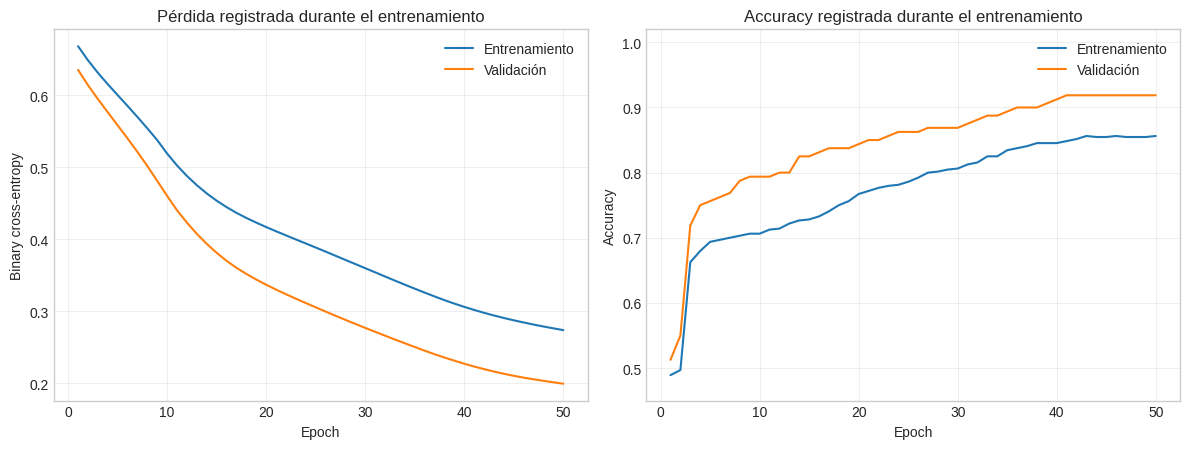

In [8]:
eje_epochs = np.arange(1, len(tabla_historial) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

axes[0].plot(eje_epochs, tabla_historial["loss"], label="Entrenamiento")
axes[0].plot(eje_epochs, tabla_historial["val_loss"], label="Validación")
axes[0].set_title("Pérdida registrada durante el entrenamiento")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(eje_epochs, tabla_historial["accuracy"], label="Entrenamiento")
axes[1].plot(eje_epochs, tabla_historial["val_accuracy"], label="Validación")
axes[1].set_title("Accuracy registrada durante el entrenamiento")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.45, 1.02)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Las curvas reúnen un valor por epoch y permiten ver el proceso, no solo su punto final. Aquí las usamos para comprobar que el historial conserva información de entrenamiento y validación.

Una evolución favorable en este ejemplo no garantiza que la misma arquitectura funcione igual con otros datos ni que más epochs produzcan siempre un modelo mejor.

## 6. Evaluar y producir predicciones

Ahora utilizaremos el conjunto de prueba, que no participó del aprendizaje ni de la validación. `evaluate()` calculará la pérdida y la *accuracy* configuradas durante `compile()`.

In [9]:
perdida_test, accuracy_test = modelo.evaluate(
    X_test,
    y_test,
    verbose=0,
)

resultado_prueba = pd.DataFrame({
    "Métrica": ["Binary cross-entropy", "Accuracy"],
    "Conjunto de prueba": [perdida_test, accuracy_test],
})

display(resultado_prueba)

,Métrica,Conjunto de prueba
0,Binary cross-entropy,0.2038
1,Accuracy,0.9050


La evaluación resume el comportamiento sobre 200 observaciones que no se usaron para actualizar los parámetros. Una *accuracy* alta es un buen resultado para esta partición y este dataset sintético, pero no significa que la red sea perfecta ni que pueda generalizar a cualquier problema.

La pérdida aporta información que la *accuracy* no conserva: distingue entre probabilidades apenas correctas y predicciones correctas realizadas con mayor margen.

In [10]:
probabilidades_test = modelo.predict(X_test, verbose=0).ravel()
predicciones_test = (probabilidades_test >= 0.5).astype(int)

comparacion = pd.DataFrame({
    "x1": X_test[:10, 0],
    "x2": X_test[:10, 1],
    "Clase real": y_test[:10].astype(int),
    "Probabilidad clase 1": probabilidades_test[:10],
    "Clase predicha": predicciones_test[:10],
})
comparacion["¿Coincide?"] = (
    comparacion["Clase real"] == comparacion["Clase predicha"]
)

display(comparacion)

,x1,x2,Clase real,Probabilidad clase 1,Clase predicha,¿Coincide?
0,0.1578,0.1582,1,0.4230,0,False
1,-0.7646,0.7718,0,0.0180,0,True
2,-0.5721,0.9123,0,0.0228,0,True
3,-0.1537,0.9811,0,0.0526,0,True
4,0.5432,-0.2868,1,0.8946,1,True
5,0.1968,0.0791,1,0.5223,1,True
6,2.0794,0.2510,1,0.8517,1,True
7,0.3483,-0.1733,1,0.7931,1,True
8,0.5785,0.7787,0,0.1130,0,True
9,-0.7390,0.2461,0,0.0730,0,True


La red no devuelve inicialmente las etiquetas 0 y 1: produce una probabilidad mediante la salida sigmoid. La clase aparece después de aplicar el umbral de 0.5.

Una probabilidad elevada expresa la preferencia del modelo por la clase 1, no una garantía de corrección. La comparación permite relacionar cada salida continua con la decisión final.

## 7. Visualizar la frontera aprendida

Como el problema tiene dos variables, podemos crear una grilla de puntos, obtener una probabilidad para cada uno y colorear las regiones que el modelo asocia con ambas clases. La línea de probabilidad 0.5 representa la frontera de decisión.

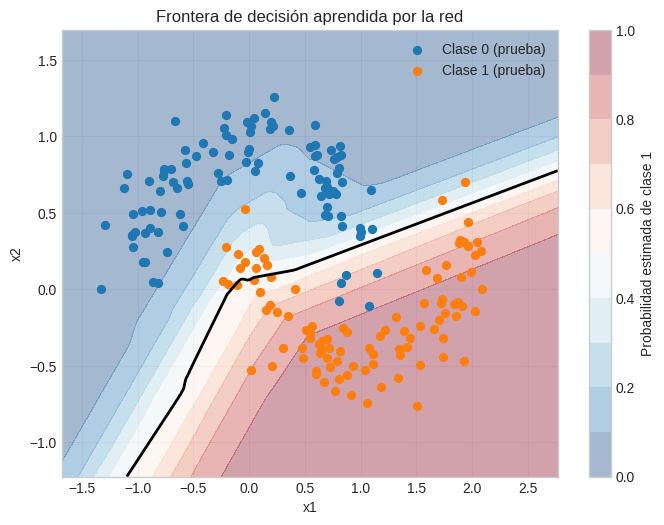

In [11]:
margen = 0.35
x1_min, x1_max = X[:, 0].min() - margen, X[:, 0].max() + margen
x2_min, x2_max = X[:, 1].min() - margen, X[:, 1].max() + margen

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 260),
    np.linspace(x2_min, x2_max, 260),
)
grilla = np.column_stack([xx1.ravel(), xx2.ravel()]).astype("float32")
probabilidades_grilla = modelo.predict(grilla, verbose=0).reshape(xx1.shape)

fig, ax = plt.subplots(figsize=(8, 5.8))
fondo = ax.contourf(
    xx1,
    xx2,
    probabilidades_grilla,
    levels=np.linspace(0, 1, 11),
    cmap="RdBu_r",
    alpha=0.38,
)
ax.contour(
    xx1,
    xx2,
    probabilidades_grilla,
    levels=[0.5],
    colors="black",
    linewidths=2,
)
ax.scatter(
    X_test[y_test == 0, 0],
    X_test[y_test == 0, 1],
    s=32,
    label="Clase 0 (prueba)",
)
ax.scatter(
    X_test[y_test == 1, 0],
    X_test[y_test == 1, 1],
    s=32,
    label="Clase 1 (prueba)",
)

barra = fig.colorbar(fondo, ax=ax)
barra.set_label("Probabilidad estimada de clase 1")
ax.set_title("Frontera de decisión aprendida por la red")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

La frontera negra no es una fórmula dibujada manualmente. Surge del efecto conjunto de los 65 pesos y bias después del entrenamiento.

Su forma curva muestra que las capas ocultas con ReLU construyeron una separación no lineal. Algunos puntos cercanos a la frontera pueden quedar del lado incorrecto debido al ruido y a la superposición de los datos.

## 8. Probar una observación nueva

La siguiente celda permite modificar las coordenadas de un punto y consultar la salida de la red. Como no conocemos su etiqueta verdadera, la predicción no puede considerarse automáticamente correcta: solo observaremos qué aprendió el modelo para esa región del plano.

Probabilidad estimada de clase 1: 0.3705
Clase predicha con umbral 0.5: 0


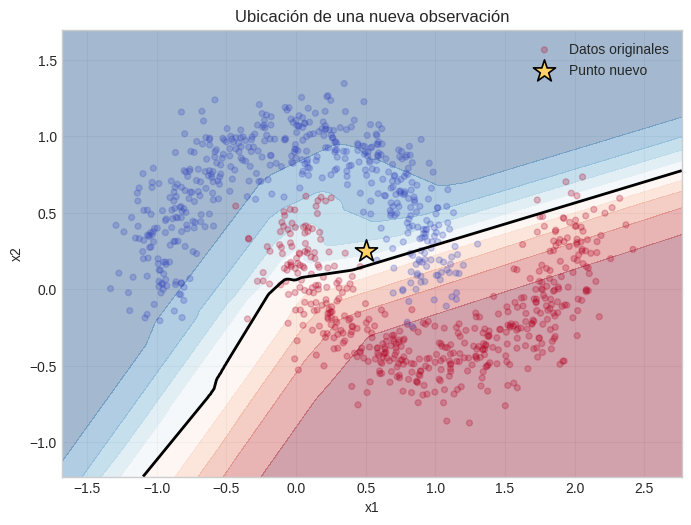

In [12]:
# Modificá estas dos coordenadas y volvé a ejecutar la celda.
punto_nuevo = np.array([[0.50, 0.25]], dtype="float32")

probabilidad_nueva = modelo.predict(punto_nuevo, verbose=0).item()
clase_nueva = int(probabilidad_nueva >= 0.5)

print(f"Probabilidad estimada de clase 1: {probabilidad_nueva:.4f}")
print(f"Clase predicha con umbral 0.5: {clase_nueva}")

fig, ax = plt.subplots(figsize=(8, 5.8))
ax.contourf(
    xx1,
    xx2,
    probabilidades_grilla,
    levels=np.linspace(0, 1, 11),
    cmap="RdBu_r",
    alpha=0.38,
)
ax.contour(
    xx1,
    xx2,
    probabilidades_grilla,
    levels=[0.5],
    colors="black",
    linewidths=2,
)
ax.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm",
    alpha=0.25,
    s=18,
    label="Datos originales",
)
ax.scatter(
    punto_nuevo[0, 0],
    punto_nuevo[0, 1],
    marker="*",
    s=280,
    color="#ffd166",
    edgecolor="black",
    linewidth=1.2,
    label="Punto nuevo",
)
ax.set_title("Ubicación de una nueva observación")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

Cambiar las coordenadas mueve el punto por regiones donde la red asigna probabilidades diferentes. Cerca de la frontera, pequeñas variaciones pueden cambiar la clase obtenida con el umbral de 0.5.

El experimento permite explorar la función aprendida, pero no reemplaza una evaluación con etiquetas verdaderas.

## 9. Del código al mecanismo

Cada instrucción principal reúne conceptos ya estudiados:

| Parte del código | Decisión o mecanismo |
|---|---|
| `Input(shape=(2,))` | Cada observación contiene dos características. |
| `Dense(8)` y `Dense(4)` | Definen las transformaciones y los parámetros entrenables. |
| `activation="relu"` | Introduce no linealidad en las capas ocultas. |
| `Dense(1, activation="sigmoid")` | Produce una probabilidad para la clase 1. |
| `loss="binary_crossentropy"` | Mide el error que se intenta reducir. |
| `optimizer="adam"` | Usa los gradientes para actualizar pesos y bias. |
| `fit(..., epochs=50, batch_size=32)` | Repite el ciclo de aprendizaje por batches y epochs. |
| `validation_split=0.2` | Registra el comportamiento sobre una porción que no actualiza parámetros. |
| `evaluate()` | Calcula pérdida y métrica sobre los datos de prueba. |
| `predict()` | Produce las salidas del modelo para nuevas entradas. |

La llamada a `fit()` es breve, pero coordina el *forward pass*, el cálculo de la pérdida, backpropagation y las actualizaciones de Adam en cada batch.

## Cierre

En este cuaderno implementamos el modelo completo presentado en el capítulo. Generamos un problema binario con dos medias lunas, reservamos datos de prueba y construimos una red con arquitectura $2
ightarrow8
ightarrow4
ightarrow1$.

Comprobamos sus 65 parámetros, configuramos Binary Cross-Entropy, Adam y *accuracy*, y entrenamos con batches de 32 observaciones durante 50 epochs. Después utilizamos el historial, evaluamos sobre datos no usados para aprender, convertimos probabilidades en clases y visualizamos la frontera no lineal obtenida.

La red ya puede aprender una función útil, pero un buen resultado final no explica por sí solo cómo evolucionó el aprendizaje. En el próximo capítulo estudiaremos con mayor cuidado las curvas de entrenamiento y validación.

## Para pensar

1. ¿Por qué la capa de entrada admite dos valores y la capa de salida contiene una sola neurona?
2. ¿Qué diferencia existe entre las probabilidades producidas por `predict()` y las clases obtenidas con el umbral de 0.5?
3. ¿Por qué los datos de prueba no deben participar del entrenamiento ni de la validación?
4. ¿Qué parte del código coordina el *forward pass*, la pérdida, backpropagation y las actualizaciones de los parámetros?